# MNIST DDPM (Simple Baseline)
This notebook implements a clean, beginner-friendly DDPM pipeline for MNIST: dependency setup, data loading, training, and sampling.


## 1) Environment Check
This cell verifies core dependencies (`torch`, `torchvision`, `matplotlib`, `tqdm`) and tries to install missing ones automatically.


In [1]:
import importlib.util
import subprocess
import sys


def ensure_packages(packages):
    missing = [p for p in packages if importlib.util.find_spec(p) is None]
    if not missing:
        print("All dependencies are available.")
        return True

    print(f"Missing packages detected: {missing}")
    print("Trying to install automatically...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
        print("Install finished.")
        return True
    except Exception as e:
        print("Automatic install failed. Please install manually and rerun this cell.")
        print(f"Reason: {e}")
        return False

DEPENDENCIES_READY = ensure_packages(["torch", "torchvision", "matplotlib", "tqdm"])


All dependencies are available.


## 2) Imports And Global Config
This cell sets random seeds for reproducibility, chooses CPU/GPU, and defines training/sampling hyperparameters.


In [2]:
if DEPENDENCIES_READY:
    import random
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader
    from torchvision import datasets, transforms
    import matplotlib.pyplot as plt
    from tqdm.auto import tqdm

    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Training config
    batch_size = 128
    lr = 2e-4
    epochs = 5

    # Diffusion config
    T = 200
    beta_start = 1e-4
    beta_end = 0.02

    # Sampling config
    sample_count = 64
else:
    print("Dependencies are not ready yet.")


Using device: cuda


c:\Users\napuc\anaconda3\envs\npcailab\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3) Load MNIST
This cell downloads MNIST, normalizes pixel values to `[-1, 1]`, and creates a training dataloader.


In [3]:
if DEPENDENCIES_READY:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])

    train_set = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=True,
    )

    print(f"Train samples: {len(train_set)}")


Train samples: 60000


## 4) DDPM Utilities
This cell builds the linear noise schedule and helper functions to gather time-dependent coefficients.


In [4]:
if DEPENDENCIES_READY:
    betas = torch.linspace(beta_start, beta_end, T, device=device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

    sqrt_alpha_bars = torch.sqrt(alpha_bars)
    sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

    def extract(coeff, t, x_shape):
        out = coeff.gather(0, t)
        return out.view(x_shape[0], 1, 1, 1)


## 5) Define A Small Noise Predictor (Simple U-Net Style)
This cell defines a lightweight CNN with sinusoidal time embedding to predict noise `epsilon_theta(x_t, t)`.


In [5]:
if DEPENDENCIES_READY:
    class SinusoidalPositionEmbeddings(nn.Module):
        def __init__(self, dim):
            super().__init__()
            self.dim = dim

        def forward(self, t):
            half_dim = self.dim // 2
            emb_scale = np.log(10000) / max(half_dim - 1, 1)
            emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb_scale)
            emb = t[:, None] * emb[None, :]
            emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
            return emb


    class ConvBlock(nn.Module):
        def __init__(self, in_ch, out_ch, stride=1):
            super().__init__()
            self.block = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1),
                nn.GroupNorm(8, out_ch),
                nn.SiLU(),
            )

        def forward(self, x):
            return self.block(x)


    class SimpleUNet(nn.Module):
        def __init__(self, time_dim=128):
            super().__init__()
            self.time_emb = nn.Sequential(
                SinusoidalPositionEmbeddings(time_dim),
                nn.Linear(time_dim, time_dim),
                nn.SiLU(),
                nn.Linear(time_dim, time_dim),
            )

            self.down1 = ConvBlock(1, 32, stride=1)
            self.down2 = ConvBlock(32, 64, stride=2)   # 28 -> 14
            self.mid = ConvBlock(64, 64, stride=1)

            self.up = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 14 -> 28
            self.up_block = ConvBlock(64, 32, stride=1)
            self.out = nn.Conv2d(32, 1, kernel_size=1)

            self.t1 = nn.Linear(time_dim, 32)
            self.t2 = nn.Linear(time_dim, 64)
            self.t3 = nn.Linear(time_dim, 64)
            self.t4 = nn.Linear(time_dim, 32)

        def forward(self, x, t):
            # Normalize time to [0, 1] before embedding for stable scale.
            t = t.float() / (T - 1)
            temb = self.time_emb(t)

            h1 = self.down1(x) + self.t1(temb)[:, :, None, None]
            h2 = self.down2(h1) + self.t2(temb)[:, :, None, None]
            h3 = self.mid(h2) + self.t3(temb)[:, :, None, None]

            u = self.up(h3) + self.t4(temb)[:, :, None, None]
            u = torch.cat([u, h1], dim=1)
            u = self.up_block(u)
            return self.out(u)


    model = SimpleUNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 165,217


## 6) Forward Diffusion And Training Loss
This cell implements the DDPM forward process `q(x_t|x_0)` and the standard MSE noise-prediction objective.


In [6]:
if DEPENDENCIES_READY:
    def q_sample(x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ab_t = extract(sqrt_alpha_bars, t, x0.shape)
        sqrt_1mab_t = extract(sqrt_one_minus_alpha_bars, t, x0.shape)
        xt = sqrt_ab_t * x0 + sqrt_1mab_t * noise
        return xt, noise


    def ddpm_loss(model, x0, t):
        xt, noise = q_sample(x0, t)
        pred_noise = model(xt, t)
        return F.mse_loss(pred_noise, noise)


## 7) Train DDPM
This cell trains the model by randomly sampling a timestep for each image and minimizing noise prediction error.


In [7]:
if DEPENDENCIES_READY:
    model.train()
    for epoch in range(epochs):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        epoch_loss = 0.0

        for x0, _ in pbar:
            x0 = x0.to(device)
            t = torch.randint(0, T, (x0.size(0),), device=device).long()

            loss = ddpm_loss(model, x0, t)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        print(f"Epoch {epoch+1}: mean loss = {epoch_loss / len(train_loader):.4f}")


Epoch 1/5: 100%|██████████| 468/468 [00:25<00:00, 18.38it/s, loss=0.1061]


Epoch 1: mean loss = 0.1496


Epoch 2/5: 100%|██████████| 468/468 [00:22<00:00, 21.07it/s, loss=0.0766]


Epoch 2: mean loss = 0.0867


Epoch 3/5: 100%|██████████| 468/468 [00:24<00:00, 18.91it/s, loss=0.0727]


Epoch 3: mean loss = 0.0782


Epoch 4/5: 100%|██████████| 468/468 [00:20<00:00, 22.88it/s, loss=0.0681]


Epoch 4: mean loss = 0.0735


Epoch 5/5: 100%|██████████| 468/468 [00:20<00:00, 22.89it/s, loss=0.0718]

Epoch 5: mean loss = 0.0712


## 8) Reverse Sampling (Generate Digits)
This cell runs the DDPM reverse process from pure Gaussian noise to clean images and visualizes generated samples.


Sampling: 100%|██████████| 200/200 [00:00<00:00, 212.51it/s]


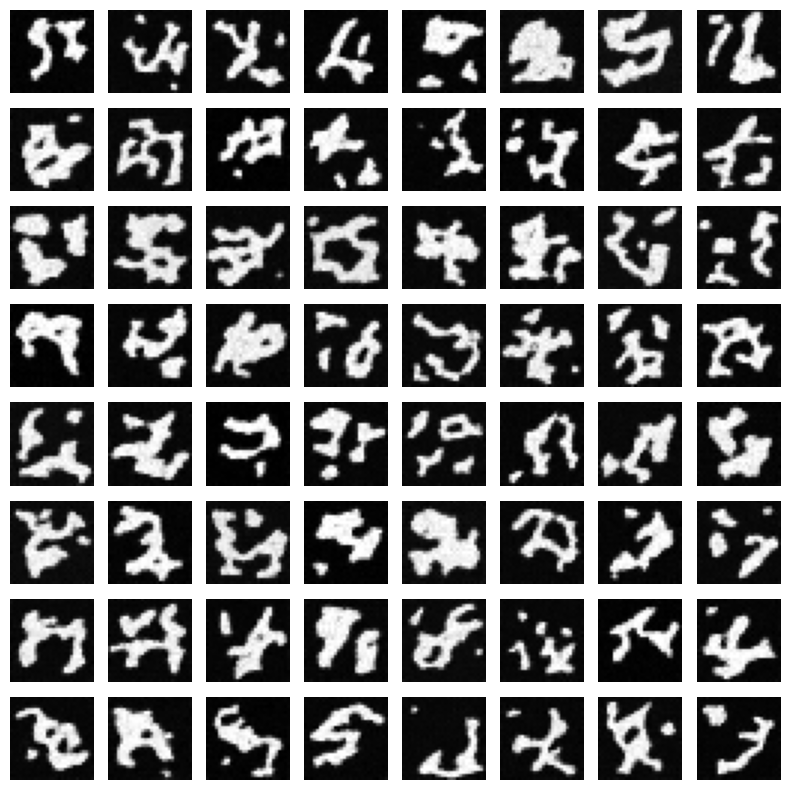

In [8]:
if DEPENDENCIES_READY:
    @torch.no_grad()
    def p_sample(model, x_t, t_scalar):
        b = x_t.shape[0]
        t = torch.full((b,), t_scalar, device=device, dtype=torch.long)

        beta_t = extract(betas, t, x_t.shape)
        sqrt_1mab_t = extract(sqrt_one_minus_alpha_bars, t, x_t.shape)
        sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x_t.shape)

        pred_noise = model(x_t, t)
        mean = sqrt_recip_alpha_t * (x_t - (beta_t / sqrt_1mab_t) * pred_noise)

        if t_scalar > 0:
            noise = torch.randn_like(x_t)
            sigma_t = torch.sqrt(beta_t)
            return mean + sigma_t * noise
        return mean


    @torch.no_grad()
    def sample_ddpm(model, n_samples=64):
        model.eval()
        x_t = torch.randn(n_samples, 1, 28, 28, device=device)
        for t in tqdm(reversed(range(T)), total=T, desc="Sampling"):
            x_t = p_sample(model, x_t, t)

        x_t = x_t.clamp(-1, 1)
        x_t = (x_t + 1) / 2
        return x_t.cpu()


    samples = sample_ddpm(model, n_samples=sample_count)

    rows = cols = int(sample_count ** 0.5)
    fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, 0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 9) Save The Trained Model (Optional)
This cell stores model weights so you can reuse them later for sampling or further training.


In [9]:
if DEPENDENCIES_READY:
    save_path = "mnist_ddpm_simple.pt"
    torch.save(model.state_dict(), save_path)
    print(f"Saved model to: {save_path}")


Saved model to: mnist_ddpm_simple.pt
